In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from cmcrameri import cm
import cartopy as cy
import cartopy.crs as ccrs
import cartopy.feature as cf
import os
from glob import glob
from functools import partial
import pickle
from matplotlib.table import Table
import numpy.ma as ma
from datetime import datetime, timedelta
import logging
import numpy as np
import matplotlib.ticker as mticker
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import partial
import pickle
from tqdm import tqdm
import pandas as pd

In [5]:
dataset = xr.open_dataset('data/traj_ds_GOFS_NexSIM_RIOPS_RIOPScoupled_ROMS_TOPAZ5_HYCOM (2).nc')

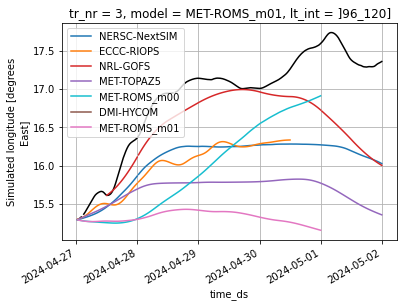

In [15]:
buoy_nr = 3
buoy_data = dataset.sel(tr_nr = buoy_nr)

colors = {
    'NERSC-NextSIM': 'tab:blue',
    'ECCC-RIOPS': 'tab:orange',
    'ECCC-RIOPScoupled': 'tab:green',
    'NRL-GOFS': 'tab:red',
    'MET-TOPAZ5': 'tab:purple',
    'MET-ROMS_m00': 'tab:cyan',
    'MET-ROMS_m01': 'tab:pink',
    'DMI-HYCOM':'tab:brown'
}

#['NERSC-NextSIM', 'ECCC-RIOPS', 'ECCC-RIOPScoupled', 'NRL-GOFS','MET-TOPAZ5', 'MET-ROMS_m00', 'MET-ROMS_m01']
#models_sel = []
models_sel = ['NERSC-NextSIM','ECCC-RIOPS', 'NRL-GOFS','MET-TOPAZ5','MET-ROMS_m00','DMI-HYCOM','MET-ROMS_m01']
target_date = '2024-04-27'  # Example date in YYYY-MM-DD format

lon_obs_b, lat_obs_b = buoy_data['lon_obs'], buoy_data['lat_obs']
plt.figure()
start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1)
end = start + pd.DateOffset(days=5)
        
lon_obs_b.sel(time_ds=slice(start,end)).plot(color='k')
for model_name in models_sel:
    color = colors.get(model_name, 'black')
    
    # Plot dummy line for legend
    plt.plot([], [], color=color, label=model_name)
    
    for k in range(0,5):
        lt_int_sel = dataset['lt_int'].values[k]
        start = pd.to_datetime(target_date) + pd.DateOffset(seconds=1) + pd.DateOffset(days=k) 
        end = start + pd.DateOffset(days=1)
        lon_sim_lt_k = buoy_data['lon_sim'].sel(model=model_name, time_ds=slice(start,end), lt_int=lt_int_sel)
        lat_sim_lt_k = buoy_data['lat_sim'].sel(model=model_name, time_ds=slice(start,end), lt_int=lt_int_sel)
        lon_sim_lt_k.plot(color=color)

plt.legend(loc='upper left')
plt.grid(True)